## Plot the training results for prediction task 

In [74]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    "font.size": 10,        # default text
    "axes.titlesize": 14,   # title
    "axes.labelsize": 12,   # axis labels
    "xtick.labelsize": 10,  # x tick labels
    "ytick.labelsize": 10,  # y tick labels
    "legend.fontsize": 10
})

result_dir = "/mnt/oss_nanhu100TB/default/zjq/results/SpecFun/result"

In [75]:
dataset = "provabgs-v2" #desi-sv1, provabgs-v2
mods = ["sp", "im", "ph", "im+ph", "sp+im", "sp+ph", "sp+im+ph"]
# mods = ["sp", "im", "sp+im", "sp+im+ph"]
# targets = ["z"]
targets = ['z', 'm_star', 'z_mw', 't_age', 'sfr']

/tmp/ipykernel_2216434/2213959388.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


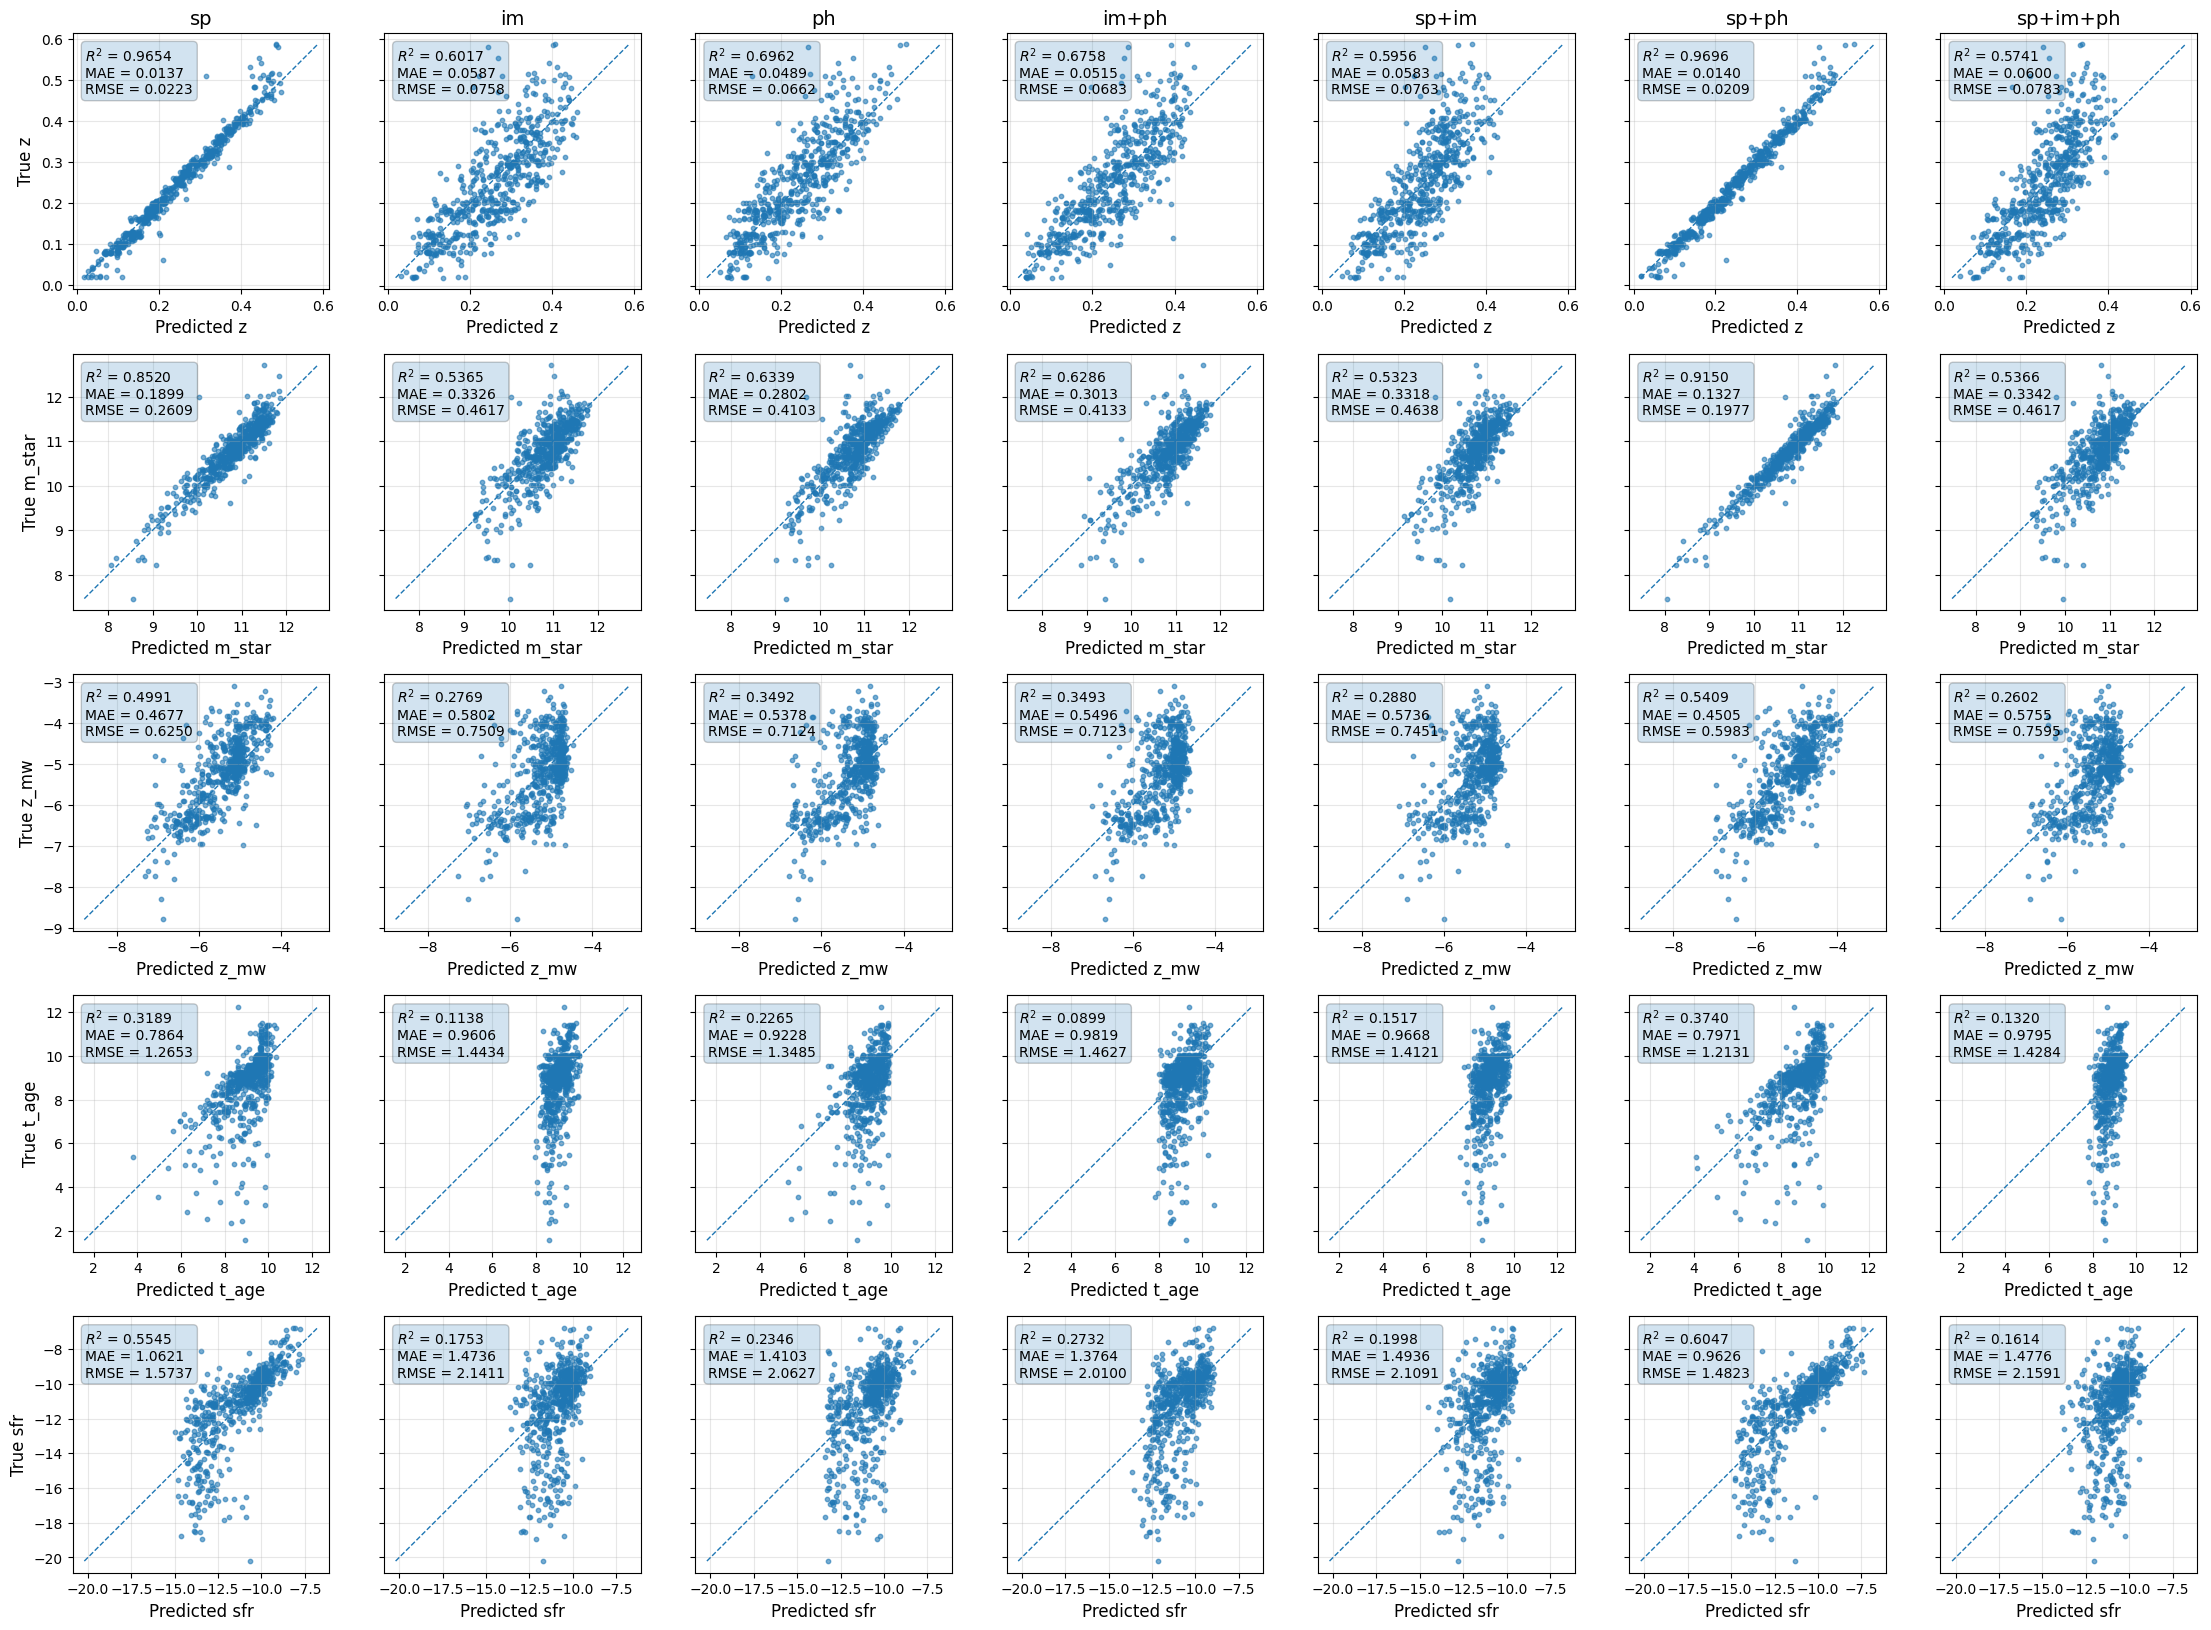

In [81]:
n_rows = len(targets)
n_cols = len(mods)

fig = plt.figure(figsize=(4*n_cols, 4*n_rows))
gs = gridspec.GridSpec(n_rows, n_cols, figure=fig, wspace=0.03, hspace=0.25)

target_tag = "_".join(targets)
for r, target in enumerate(targets):
    for c, mod in enumerate(mods):
        ax = fig.add_subplot(gs[r, c])

        # --- load data on the fly ---
        prefix = f"{dataset}_{mod}_{target_tag}"
        pred_file = os.path.join(result_dir, f"{dataset}", f"{prefix}_test_predict.npz")
        data = np.load(pred_file, allow_pickle=True)

        test_true = data["test_true"]
        test_pred = data["test_pred"]
        label_names = list(data["label_names"])

        idx = label_names.index(target)
        y_true = test_true[:, idx]
        y_pred = test_pred[:, idx]

        # --- metrics ---
        r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
        mae = np.mean(np.abs(y_true - y_pred))
        rmse = np.sqrt(np.mean((y_true - y_pred)**2))

        # --- plot ---
        ax.scatter(y_pred, y_true, s=10, alpha=0.6)
        xmin = min(y_true.min(), y_pred.min())
        xmax = max(y_true.max(), y_pred.max())
        ax.plot([xmin, xmax], [xmin, xmax], "--", linewidth=1)
        ax.set_aspect("equal", adjustable="box")

        if r == 0:
            ax.set_title(mod)
        if c == 0:
            ax.set_ylabel(f"True {target}")
        else:
            ax.tick_params(labelleft=False)

        ax.set_xlabel(f"Predicted {target}")

        ax.text(
            0.05, 0.95,
            f"$R^2$ = {r2:.4f}\nMAE = {mae:.4f}\nRMSE = {rmse:.4f}",
            transform=ax.transAxes,
            va="top", ha="left",
            bbox=dict(boxstyle="round", alpha=0.2)
        )
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2216434/2106293613.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


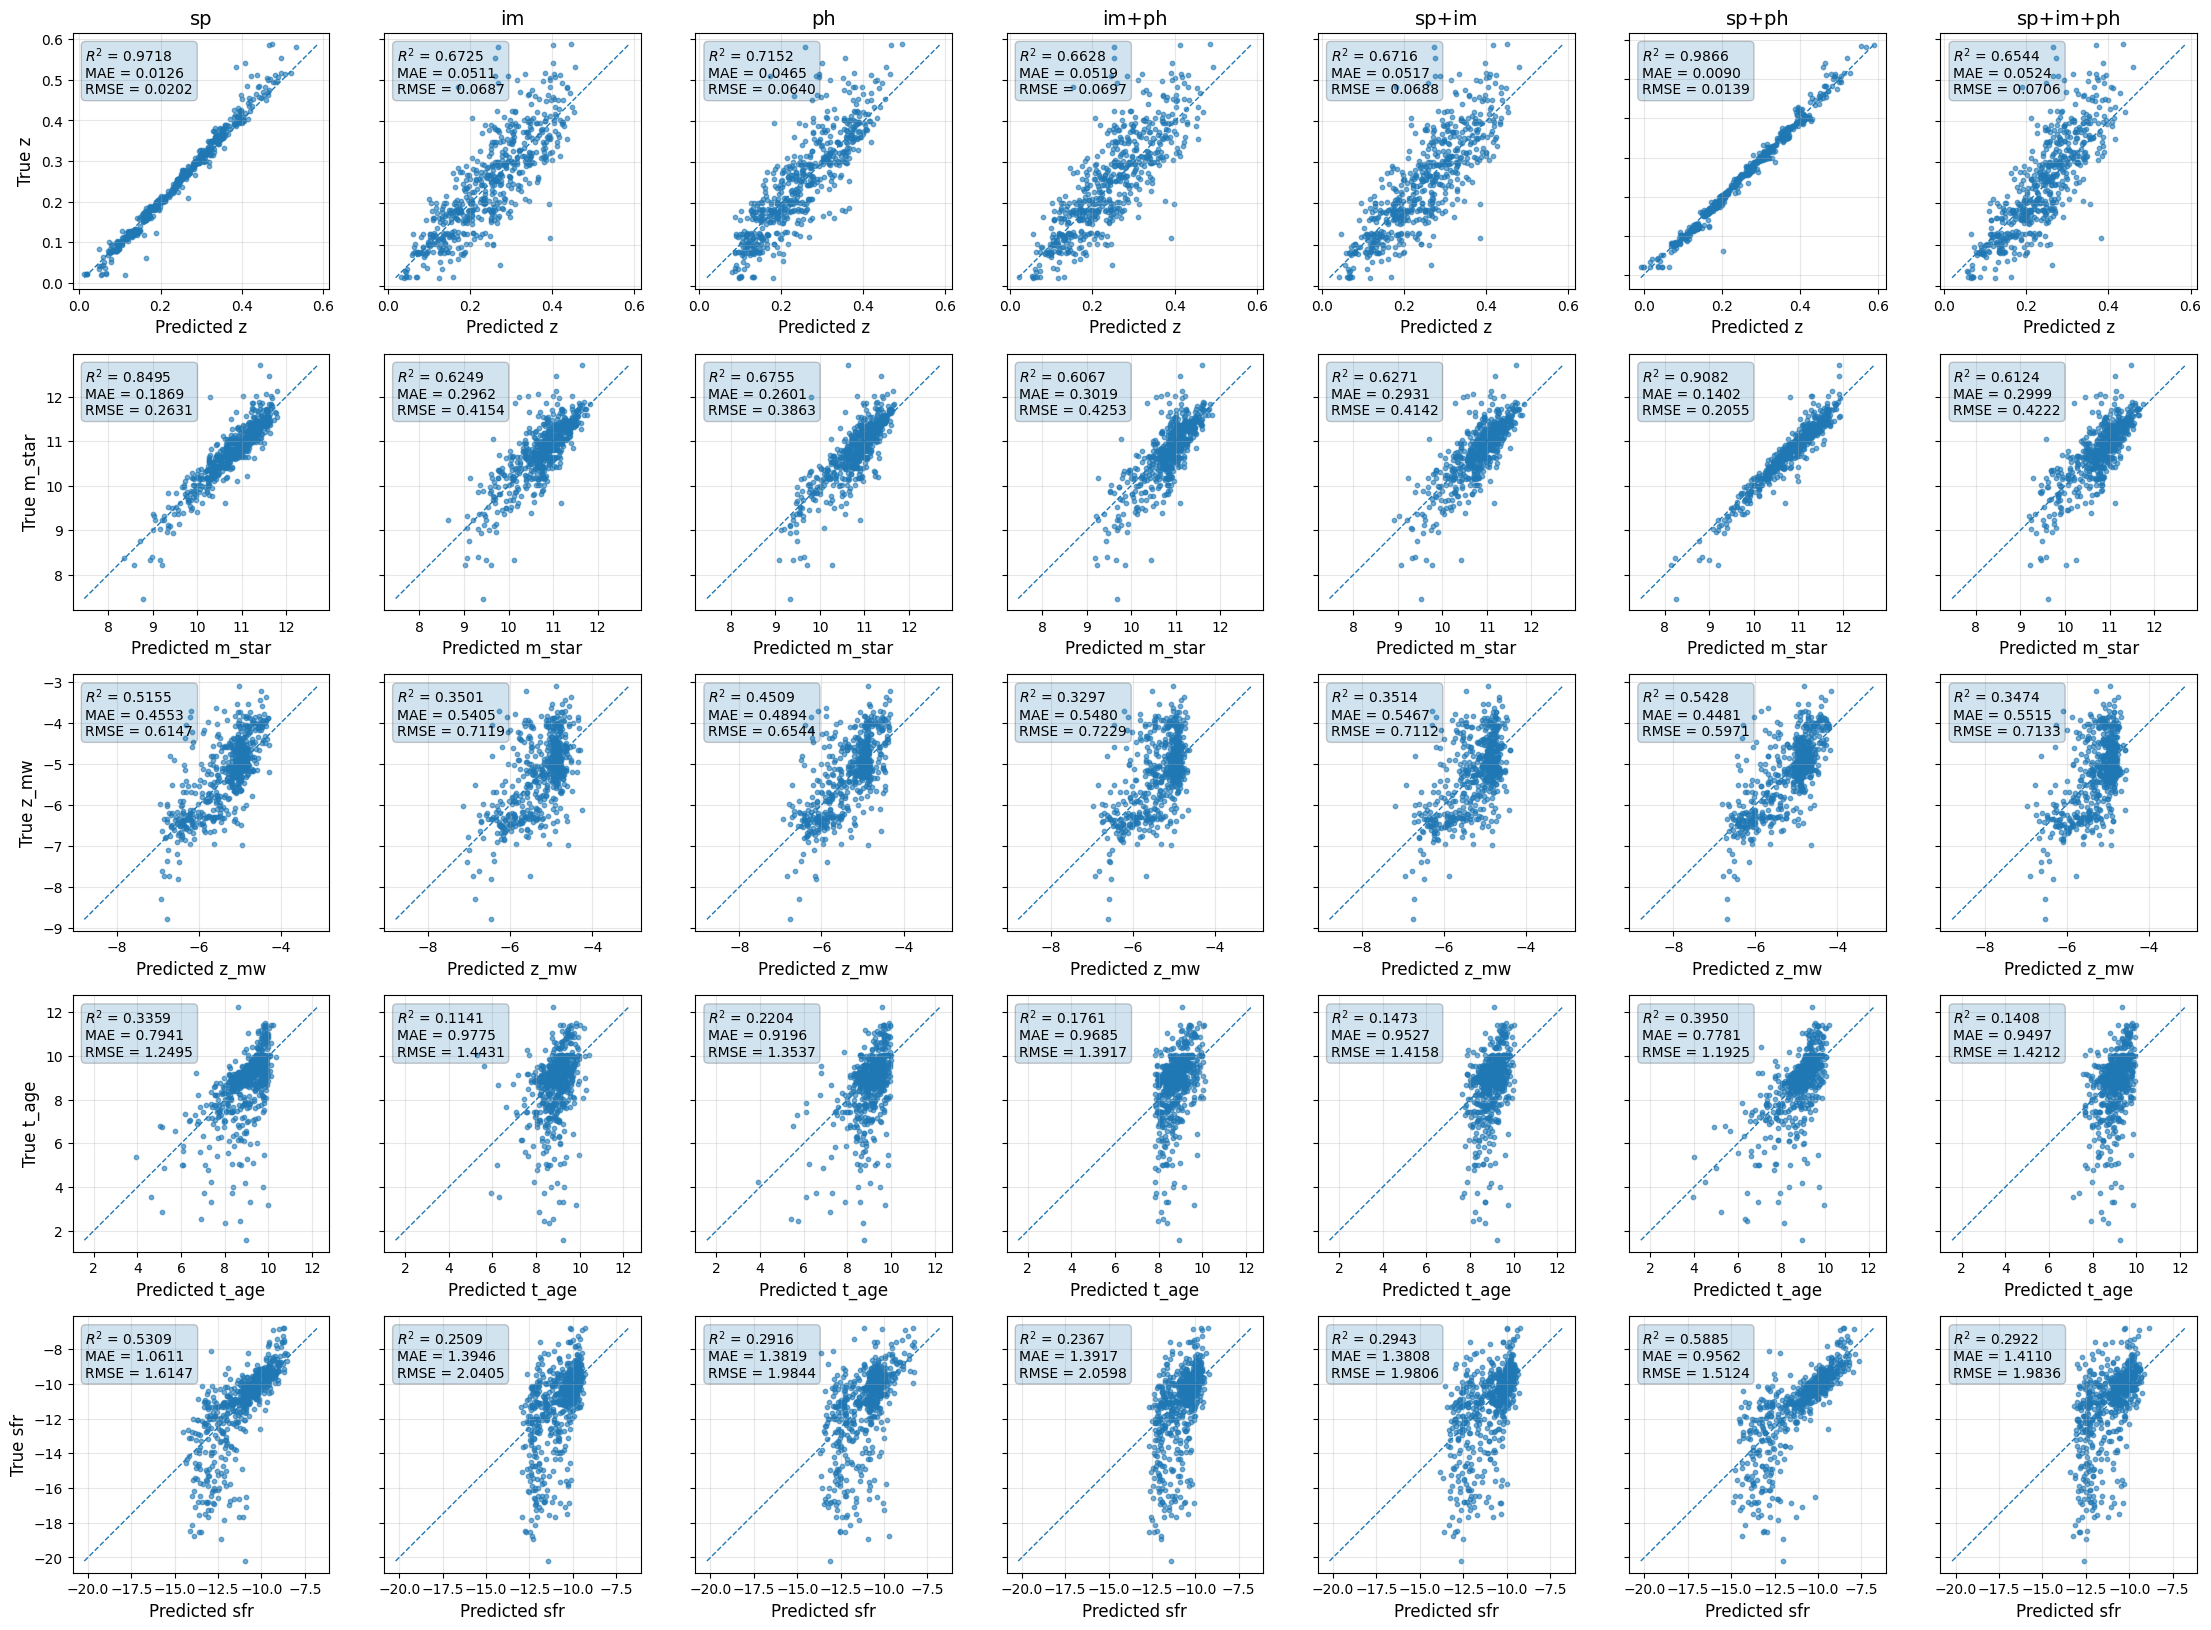

In [84]:
n_rows = len(targets)
n_cols = len(mods)

fig = plt.figure(figsize=(4*n_cols, 4*n_rows))
gs = gridspec.GridSpec(n_rows, n_cols, figure=fig, wspace=0.03, hspace=0.25)

for r, target in enumerate(targets):
    for c, mod in enumerate(mods):
        ax = fig.add_subplot(gs[r, c])

        # --- load data on the fly ---
        #### we changed here
        target_tag = target
        prefix = f"{dataset}_{mod}_{target_tag}"
        pred_file = os.path.join(result_dir, f"{dataset}", f"{prefix}_test_predict.npz")
        data = np.load(pred_file, allow_pickle=True)

        test_true = data["test_true"]
        test_pred = data["test_pred"]
        label_names = list(data["label_names"])

        idx = label_names.index(target)
        y_true = test_true[:, idx]
        y_pred = test_pred[:, idx]

        # --- metrics ---
        r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
        mae = np.mean(np.abs(y_true - y_pred))
        rmse = np.sqrt(np.mean((y_true - y_pred)**2))

        # --- plot ---
        ax.scatter(y_pred, y_true, s=10, alpha=0.6)
        xmin = min(y_true.min(), y_pred.min())
        xmax = max(y_true.max(), y_pred.max())
        ax.plot([xmin, xmax], [xmin, xmax], "--", linewidth=1)
        ax.set_aspect("equal", adjustable="box")

        if r == 0:
            ax.set_title(mod)
        if c == 0:
            ax.set_ylabel(f"True {target}")
        else:
            ax.tick_params(labelleft=False)

        ax.set_xlabel(f"Predicted {target}")

        ax.text(
            0.05, 0.95,
            f"$R^2$ = {r2:.4f}\nMAE = {mae:.4f}\nRMSE = {rmse:.4f}",
            transform=ax.transAxes,
            va="top", ha="left",
            bbox=dict(boxstyle="round", alpha=0.2)
        )
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
## Direct Z Inference Test

99.23984272608126
51.53342070773264
1.2844036697247707
65.5570117955439
99.39711664482307
99.10878112712976
99.39711664482307


/tmp/ipykernel_2216434/989103427.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


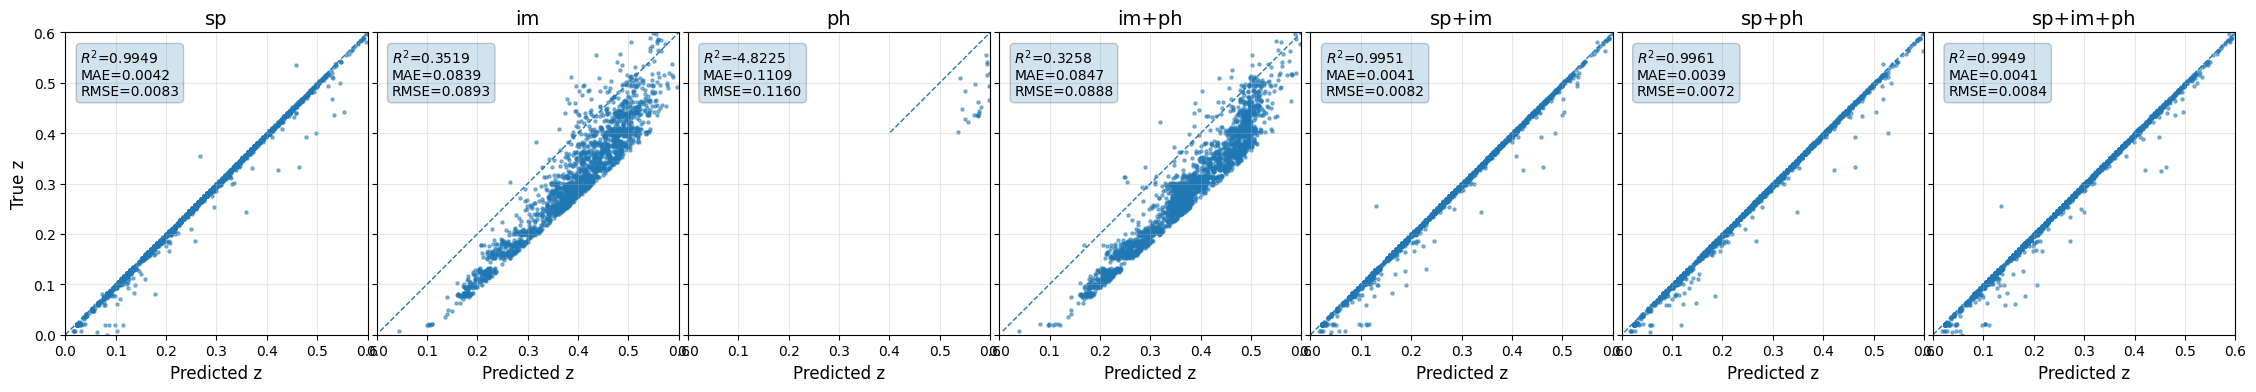

In [101]:
dataset = "provabgs-v2" # "desi-sv1", "provabgs-v2"

mods = ["sp", "im", "ph", "im+ph", "sp+im", "sp+ph", "sp+im+ph"][:] 
# mods = ["sp", "sp+im", "sp+ph", "sp+im+ph"][:]   # or full list later
# or full list later

n_cols = len(mods)

fig = plt.figure(figsize=(4*n_cols, 4))
gs = gridspec.GridSpec(1, n_cols, figure=fig, wspace=0.03)
for c, mod in enumerate(mods):
    prefix = f"{dataset}_{mod}_direct_z"
    pred_file = os.path.join(result_dir, f"{dataset}", f"{prefix}_test_predict.npz")
    data = np.load(pred_file, allow_pickle=True)
    y_true = data["z_true"]
    y_pred = data["z_pred"]

    dz = np.abs(y_true-y_pred)/(1+y_true)
    
    mask = (dz<0.1)
    print(f"{np.mean(mask)*100}")
    y_true =y_true[mask]
    y_pred =y_pred[mask]
    
    # metrics
    r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)
    mae = np.mean(np.abs(y_true - y_pred))
    
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    
    ax = fig.add_subplot(gs[0, c])
    ax.scatter(y_pred, y_true, s=5, alpha=0.5)
    xmin = min(y_true.min(), y_pred.min())
    xmax = max(y_true.max(), y_pred.max())
    ax.plot([xmin, xmax], [xmin, xmax], "--", linewidth=1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(mod)
    ax.set_xlabel("Predicted z")
    if c == 0:
        ax.set_ylabel("True z")
    else:
        ax.tick_params(labelleft=False)

    ax.text(
        0.05, 0.95,
        f"$R^2$={r2:.4f}\nMAE={mae:.4f}\nRMSE={rmse:.4f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round", alpha=0.2)
    )
    if dataset in ["provabgs-v2"]:
        ax.set_xlim([0,0.6])
        ax.set_ylim([0,0.6])
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
print(0.0032*300000)

960.0
